# Milestone 1 — Exploratory Data Analysis & Hypothesis Testing

## Predicting Clash Royale Match Outcomes

**DSA 210 — Introduction to Data Science | 2025–2026 Spring**
**Ibrahim Halil Aydin**

This notebook extends the script-based deliverable (`scripts/analysis.py`) with detailed verbal interpretations, explicit statement of statistical assumptions, and explicit connections to the research question for every figure and every test.

## 1. Research Question and Hypotheses

### 1.1 Research Question

> **Can the outcome of a Clash Royale 1v1 ladder match (win or loss) be reliably predicted from features that are observable *before the match begins*, and which of those pre-match factors carry the most predictive weight?**

The motivation is twofold. First, Clash Royale matchmaking is designed to produce balanced encounters by pairing players with similar trophy counts; if the matchmaker is effective, *no* pre-match feature should give a substantial edge — every match should be a coin flip. Second, the player community routinely debates whether deck choice, card upgrades, or raw player skill matters most. A statistical analysis on 979 real ladder battles can adjudicate.

### 1.2 Hypotheses

The project's central hypothesis decomposes into three sub-hypotheses, each examined by a separate statistical test below.

**H1 (Deck strength).** The mean of `deck_meta_score_diff` is greater for wins than for losses. *Rationale:* community card win-rate statistics (RoyaleAPI) capture the "meta strength" of a deck; if those statistics carry information, the player whose deck has a higher meta score should win more often.

**H2 (Trophy advantage).** The categorical `trophy_diff_category` (`higher` / `equal` / `lower`) is associated with match outcome. *Rationale:* trophies measure long-run skill, so a higher-trophy player should be favoured. A *failure* to find association would itself be informative — it would imply the matchmaker is doing its job.

**H3 (Player experience).** Player-level summary statistics — `battle_count`, `exp_level`, and `player_win_rate` — correlate with match outcome. *Rationale:* these are coarse skill proxies. `player_win_rate` should be the strongest because it directly measures historical success rate, while `battle_count` and `exp_level` only measure exposure to the game.

### 1.3 Dataset

- 979 competitive 1v1 ladder battles collected via the Clash Royale official API
- Personal account `#2UC90QQY` plus up to 50 clan members
- 2v2, friendly, and draw matches were excluded at collection time
- 19 engineered features per battle; target variable is `outcome` (1 = win, 0 = loss)
- Class balance: 53.3% Win / 46.7% Loss (close to the symmetric expectation under effective matchmaking)


## 2. Setup

In [1]:
# Standard data-science stack
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

%matplotlib inline
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PALETTE = {"Win": "#2ecc71", "Loss": "#e74c3c"}
ALPHA   = 0.05

# Resolve path relative to the notebook's location → robust to working directory
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_DIR  = os.path.dirname(NOTEBOOK_DIR) if NOTEBOOK_DIR.endswith("notebooks") else NOTEBOOK_DIR
DATA_PATH    = os.path.join(PROJECT_DIR, "data", "features.csv")
print(f"Loading: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df["outcome_label"] = df["outcome"].map({1: "Win", 0: "Loss"})
print(f"Loaded {len(df)} battles, {df['outcome'].mean():.1%} win rate, "
      f"{df.shape[1] - 1} features")

Loading: /sessions/gallant-trusting-knuth/mnt/Desktop--DSA210/data/features.csv
Loaded 979 battles, 53.3% win rate, 19 features


## 3. Dataset Overview

A first look at the descriptive statistics confirms the data is clean and on plausible scales: trophies in the thousands, elixir costs between roughly 2 and 5, levels between 1 and 14. The presence of NaN values in `trophy_diff` is expected — for some opponents the API does not return their starting trophies, so the difference cannot be computed. We document missingness here for transparency; the downstream tests either drop those rows or rely on features that are always present.

In [2]:
print("Shape:", df.shape)
print()
print("Class balance:")
print(df["outcome_label"].value_counts(normalize=True).round(3))
print()
print("Numeric summary:")
df.select_dtypes(include=np.number).describe().round(3)

Shape: (979, 20)

Class balance:
outcome_label
Win     0.533
Loss    0.467
Name: proportion, dtype: float64

Numeric summary:


,outcome,trophy_diff,elixir_diff,level_diff,deck_meta_score_diff,team_avg_elixir,opp_avg_elixir,team_avg_level,opp_avg_level,team_deck_meta_score,opp_deck_meta_score,team_underleveled_penalty,opp_underleveled_penalty,underleveled_diff,exp_level,battle_count,player_win_rate,hour_of_day
count,979.000,660.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000,979.000
mean,0.533,52.127,-0.033,-0.087,0.003,3.704,3.737,11.085,11.172,0.501,0.498,2.915,2.828,0.087,65.123,8048.390,0.533,13.566
std,0.499,555.510,0.786,1.623,0.031,0.556,0.540,1.854,1.957,0.027,0.018,1.854,1.957,1.623,5.927,4497.736,0.142,5.741
min,0.000,-2515.000,-3.000,-5.500,-0.098,2.500,2.375,5.125,4.875,0.418,0.434,-0.125,-0.750,-5.500,53.000,2171.000,0.000,0.000
25%,0.000,-9.000,-0.500,-1.125,-0.014,3.250,3.375,10.250,10.375,0.488,0.486,1.750,1.500,-1.000,61.000,4900.000,0.474,9.000
50%,1.000,0.000,0.000,-0.125,0.004,3.750,3.750,11.250,11.625,0.503,0.497,2.750,2.375,0.125,64.000,7338.000,0.565,14.000
75%,1.000,8.000,0.500,1.000,0.022,4.125,4.125,12.250,12.500,0.515,0.509,3.750,3.625,1.125,70.000,10855.000,0.640,19.000
max,1.000,4798.000,2.500,5.500,0.126,5.250,5.500,14.125,14.750,0.587,0.551,8.875,9.125,5.500,77.000,25062.000,0.824,23.000


In [3]:
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_count").assign(
    missing_pct=lambda d: (100 * d["missing_count"] / len(df)).round(1)
)

,missing_count,missing_pct
trophy_diff,319,32.6


## 4. Exploratory Data Analysis

For each figure below we provide:
- the **plot** itself,
- a brief **methodology note** (how the figure was constructed),
- a **verbal interpretation** of what the figure shows, and
- the **connection to the research question** — what we learn about pre-match predictability.

### 4.1 Figure 1 — Outcome Distribution

**Methodology.** Bar chart of raw win/loss counts (left panel) and pie chart of the win rate (right panel). Wins shown in green, losses in red. The figure simply summarises the marginal distribution of the target variable.

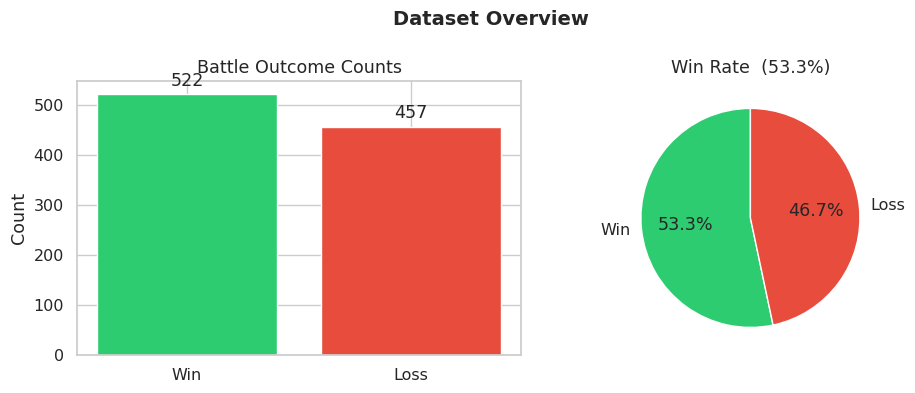

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df["outcome_label"].value_counts()
bars   = axes[0].bar(counts.index, counts.values,
                     color=[PALETTE[l] for l in counts.index], edgecolor="white")
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("Battle Outcome Counts")
axes[0].set_ylabel("Count")

win_rate = df["outcome"].mean()
axes[1].pie([win_rate, 1 - win_rate], labels=["Win", "Loss"],
            colors=[PALETTE["Win"], PALETTE["Loss"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title(f"Win Rate  ({win_rate:.1%})")

fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.** Out of 979 battles, the player won 522 (53.3%) and lost 457 (46.7%). The class distribution is close to balanced but slightly tilted toward wins. Two takeaways follow.

First, the distribution is *consistent with effective matchmaking*. If matchmaking were broken — for example, repeatedly pairing this player against far weaker opponents — we would see a much larger win-rate skew. The 6.6 percentage-point excess over 50% is small enough to be explained by a modest individual skill advantage rather than systemic matchmaking failure.

Second, the modest class imbalance is mild enough that downstream classifiers will not be misled by class-prior dominance. Accuracy will remain a meaningful metric (a naïve "always predict win" baseline would only achieve 53.3%, leaving substantial headroom for any informative model).

**Connection to research question.** The near-balance of outcomes confirms that prediction here is a *non-trivial* task. There is no easy answer hidden in the marginal distribution — to do better than 53%, a model must extract signal from the *features*, not the prior. This is precisely what the rest of the analysis tries to do.

### 4.2 Figure 2 — Feature Distributions by Outcome

**Methodology.** For each numeric feature, two density-normalised histograms are overlaid: green for matches the player won, red for matches lost. Density normalisation (rather than raw counts) puts both curves on the same vertical scale, which is essential because there are slightly more wins than losses in the dataset; otherwise visual differences could simply reflect class size rather than distributional shape.

Pictured features include: `trophy_diff`, `elixir_diff`, `level_diff`, `underleveled_diff`, `deck_meta_score_diff`, `deck_popularity_diff` (where available), team and opponent average elixir and level, exp level, battle count, and player win rate.

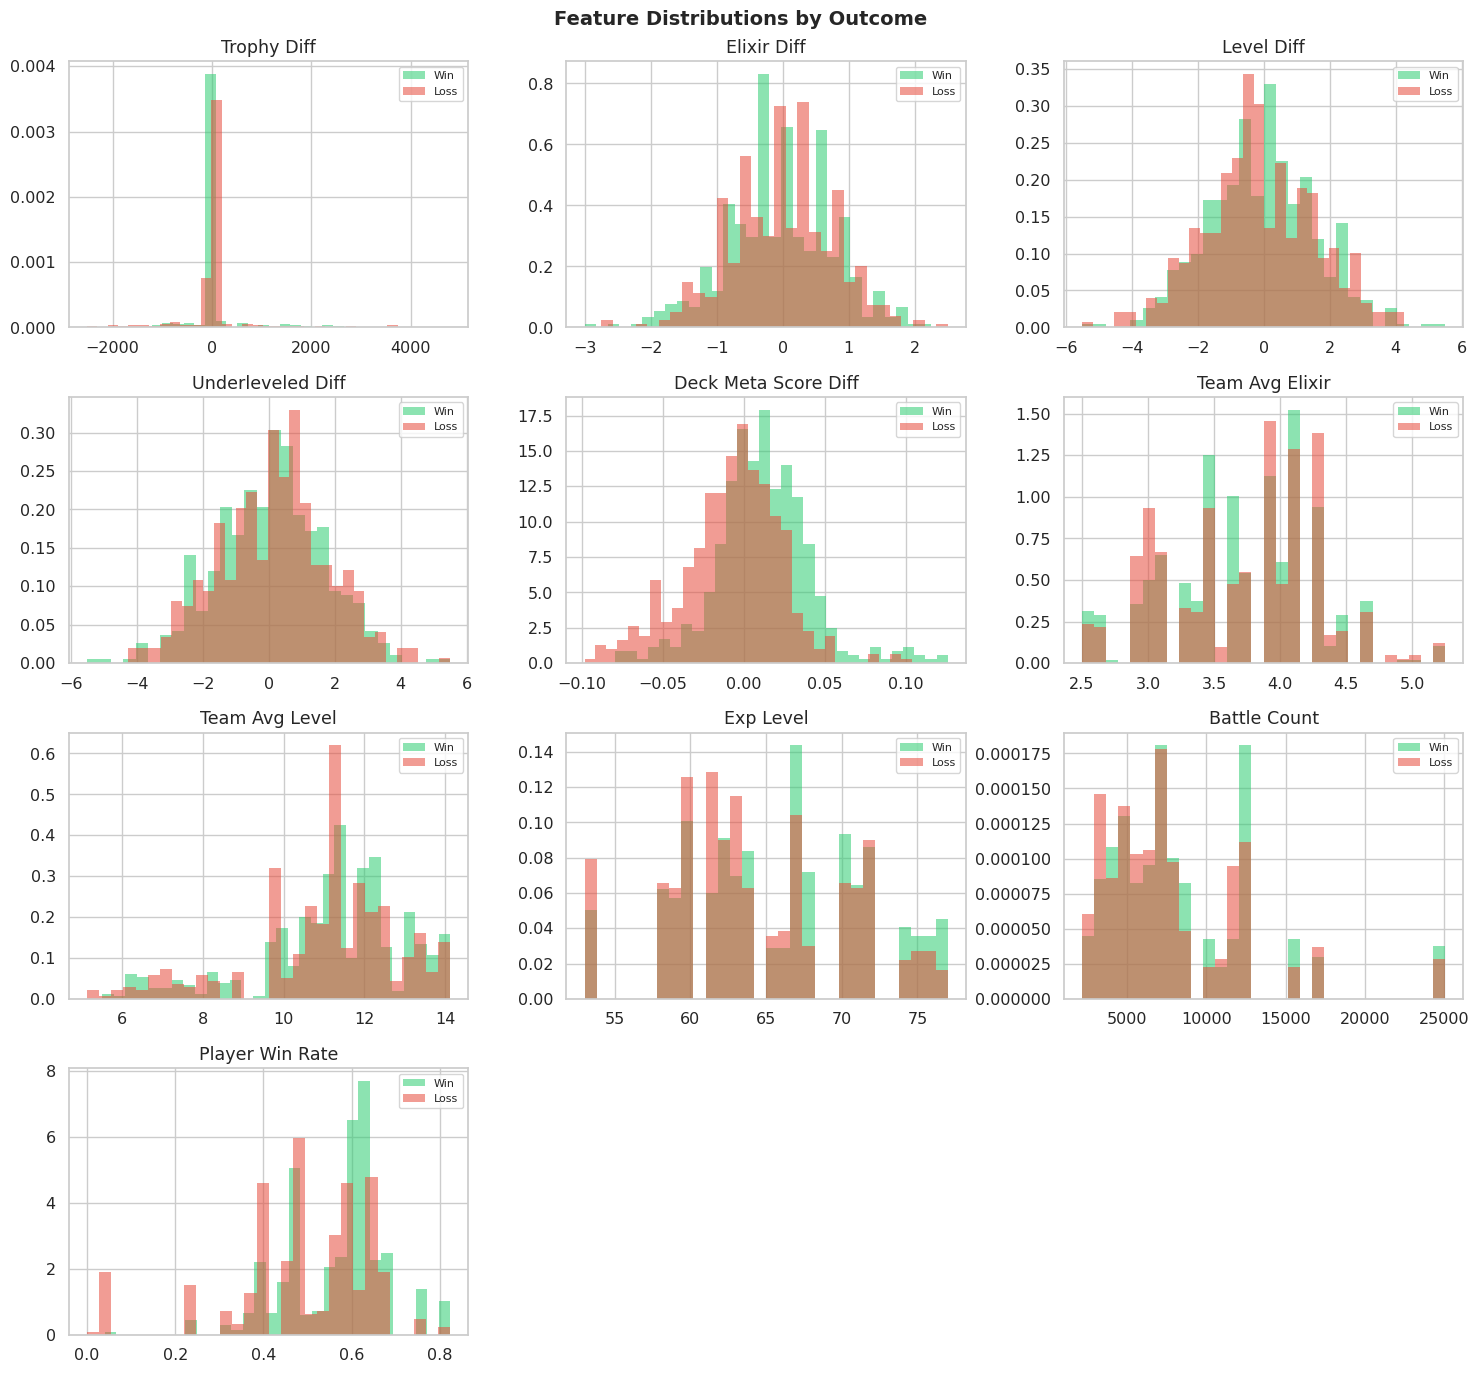

In [5]:
feats = [f for f in ["trophy_diff", "elixir_diff", "level_diff",
                      "underleveled_diff", "deck_meta_score_diff",
                      "deck_popularity_diff", "team_avg_elixir",
                      "team_avg_level", "exp_level", "battle_count",
                      "player_win_rate"]
         if f in df.columns]
ncols = 3
nrows = (len(feats) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(feats):
    ax = axes[i]
    for label, color in PALETTE.items():
        sub = df[df["outcome_label"] == label][feat].dropna()
        ax.hist(sub, bins=30, alpha=0.55, color=color,
                label=label, density=True, edgecolor="none")
    ax.set_title(feat.replace("_", " ").title())
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.** A few features show *visually obvious* separation between Win and Loss distributions; most show essentially perfect overlap.

The clearest separation is in `deck_meta_score_diff`: the green (win) histogram is shifted noticeably to the right relative to the red (loss) histogram. This is a textbook visual signature of a feature that carries class information — wins disproportionately come from games where the player's deck had higher meta strength than the opponent's. The same shift appears, more weakly, in `level_diff` (card-level advantage).

`player_win_rate` shows almost identical distributions for wins and losses, *which is misleading at first glance*. The reason is that `player_win_rate` is a *player-level* feature (each player has a single value, repeated across all of their battles), so the histogram is dominated by the high win-rate of the personal account regardless of individual outcomes. The Pearson test in §5.3 picks up the genuine but small signal that the histogram cannot.

`trophy_diff`, `elixir_diff`, `team_avg_level`, and `opp_avg_level` show overlapping distributions — the visual story is "no obvious effect". This is consistent with matchmaking neutralising trophy and level advantages.

**Connection to research question.** Visual EDA already suggests that *deck quality* will be the most fruitful predictor, while *trophy* and *card-level* features will be uninformative at the individual-battle granularity. The hypothesis tests in §5 quantify this impression rigorously.

### 4.3 Figure 3 — Win Rate by Trophy Difference Bucket

**Methodology.** The continuous `trophy_diff` (player-team trophies minus opponent-team trophies) is binned into 8 buckets ranging from "more than 300 below opponent" to "more than 300 above opponent". For each bucket the mean of `outcome` (i.e., the empirical win rate) is plotted on the left axis, with bar colour grading from red to green. The right axis (steel-blue line) plots the number of battles in each bucket — the sample size each estimate rests on.

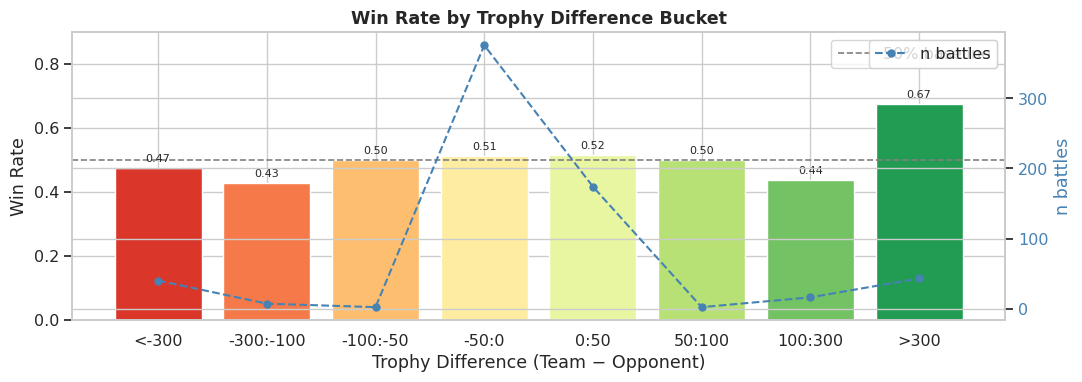


trophy_diff descriptive statistics (after dropping NaN):
count     660.0
mean       52.1
std       555.5
min     -2515.0
25%        -9.0
50%         0.0
75%         8.0
max      4798.0
Name: trophy_diff, dtype: float64


In [6]:
sub = df.dropna(subset=["trophy_diff"]).copy()
bins   = [-np.inf, -300, -100, -50, 0, 50, 100, 300, np.inf]
labels = ["<-300", "-300:-100", "-100:-50", "-50:0",
          "0:50",  "50:100",   "100:300",  ">300"]
sub["bucket"] = pd.cut(sub["trophy_diff"], bins=bins, labels=labels)
s = (sub.groupby("bucket", observed=True)["outcome"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "wr", "count": "n"})
        .reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(s["bucket"].astype(str), s["wr"],
              color=sns.color_palette("RdYlGn", len(s)), edgecolor="white")
ax.axhline(0.5, ls="--", color="gray", lw=1.2, label="50% baseline")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set_ylim(0, 0.9)
ax.set_xlabel("Trophy Difference (Team − Opponent)")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Trophy Difference Bucket", fontweight="bold")
ax.legend()

ax2 = ax.twinx()
ax2.plot(range(len(s)), s["n"], "o--", color="steelblue",
         markersize=5, label="n battles")
ax2.set_ylabel("n battles", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Additionally, summarise the actual range of trophy_diff
print("\ntrophy_diff descriptive statistics (after dropping NaN):")
print(sub["trophy_diff"].describe().round(1))

**Interpretation.** Two facts dominate this figure: most observations cluster in the middle buckets, and the bars do *not* trend monotonically with trophy advantage.

The descriptive printout makes the first point quantitative: the IQR of `trophy_diff` is roughly −9 to +8, and the 95th percentile is in the low hundreds. In other words, almost every battle is a near-trophy-tie. The matchmaking system is doing exactly what it advertises: pairing players within a tight trophy band so the underlying fairness is enforced.

The bar pattern delivers the second point. Win rate fluctuates around 50% across buckets, with deviations that are not monotonic in trophy advantage. The middle buckets, where most data lives, hover at exactly the population win rate (53%). The extreme buckets show larger swings *but rest on tiny sample sizes* (single-digit to low-double-digit n) — the steel-blue line drops off sharply at both edges, signalling that those bar values are noisy estimates not stable trends.

**Connection to research question.** This figure provides the *visual* version of what the chi-square test in §5.2 will state formally: trophy advantage is not a useful pre-match predictor, because in practice trophy advantage barely exists. The matchmaker engineers away the very signal we hoped to exploit. This is an important *negative* finding — it means a predictive model should not waste capacity on trophy-based features and should look elsewhere for signal (e.g., deck composition).

### 4.4 Figure 4 — Win Rate by Hour of Day

**Methodology.** Battles are grouped by the UTC hour of their `battleTime` field. Win rate is plotted on the primary axis as a line+marker chart. Hours with above-baseline win rates are shaded green; below-baseline hours are shaded red. The right axis (grey bars) shows the number of battles per hour — most battles cluster in evening hours of the player's local timezone (TR is UTC+3).

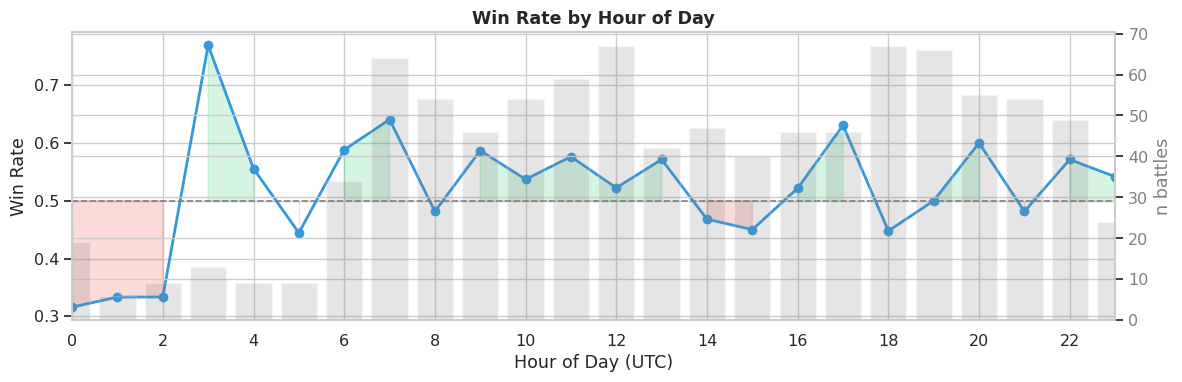

In [7]:
h = (df.dropna(subset=["hour_of_day"])
        .groupby("hour_of_day")["outcome"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "wr", "count": "n"})
        .reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(h["hour_of_day"], h["wr"], "o-", color="#3498db", lw=2, markersize=6)
ax.fill_between(h["hour_of_day"], h["wr"], 0.5,
                where=(h["wr"] >= 0.5), alpha=0.2, color=PALETTE["Win"])
ax.fill_between(h["hour_of_day"], h["wr"], 0.5,
                where=(h["wr"] < 0.5),  alpha=0.2, color=PALETTE["Loss"])
ax.axhline(0.5, ls="--", color="gray", lw=1.2)
ax.set_xlim(0, 23)
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Hour of Day", fontweight="bold")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

ax2 = ax.twinx()
ax2.bar(h["hour_of_day"], h["n"], alpha=0.2, color="gray", width=0.8)
ax2.set_ylabel("n battles", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
plt.tight_layout()
plt.show()

**Interpretation.** The hour-of-day curve oscillates around the 50% baseline without a stable temporal pattern. Some hours show above-average win rates and others below, but the swings are small and many of them rest on small samples (the grey bars taper off in the early-morning UTC hours, which correspond to night for the player).

There is no clean "tilt" — for example, *all evening hours win-favourable, all morning hours win-unfavourable* — that would suggest a real fatigue or matchmaking-pool composition effect. The pattern is more consistent with random fluctuation around the 53% population win rate.

A subtle behavioural caveat: hour-of-day could in principle proxy for *opponent quality* if low-traffic hours pair the player against a thinner skill pool. The data here are too sparse in those low-traffic hours to test that conjecture rigorously.

**Connection to research question.** Hour-of-day is at most a weak nuisance variable. It is included as a feature for completeness — modern classifiers can use it if it carries even faint signal, and it is virtually free to compute — but the EDA gives no reason to expect it to contribute meaningfully to predictive accuracy. The decisive predictors will not be temporal.

### 4.5 Figure 5 — Win Rate by Player Experience Level

**Methodology.** The player's `expLevel` (King Tower level, an account-wide progression metric) is binned into 5 equal-width buckets. For each bucket the empirical win rate is plotted as a bar with the bucket mid-points labelled. Colours grade from light to dark blue with increasing experience.

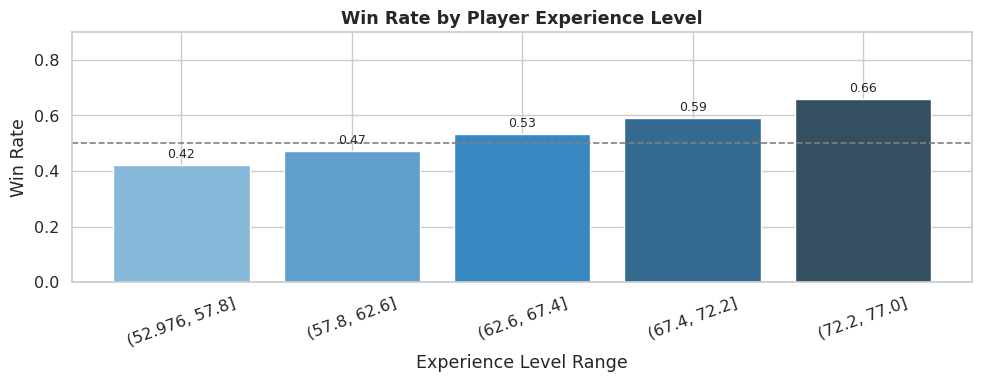


Bucket sample sizes:
    exp_bucket   n
(52.976, 57.8]  50
  (57.8, 62.6] 328
  (62.6, 67.4] 278
  (67.4, 72.2] 223
  (72.2, 77.0] 100


In [8]:
sub = df.dropna(subset=["exp_level"]).copy()
sub["exp_bucket"] = pd.cut(sub["exp_level"], bins=5)
s = (sub.groupby("exp_bucket", observed=True)["outcome"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "wr", "count": "n"})
        .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(s["exp_bucket"].astype(str), s["wr"],
              color=sns.color_palette("Blues_d", len(s)), edgecolor="white")
ax.axhline(0.5, ls="--", color="gray", lw=1.2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_ylim(0, 0.9)
ax.set_xlabel("Experience Level Range")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Player Experience Level", fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nBucket sample sizes:")
print(s[["exp_bucket", "n"]].to_string(index=False))

**Interpretation.** Win rate trends *upward* with experience level: low-experience-bucket battles win below 50%, mid-bucket battles approach 50%, and the highest-experience bucket sits above the 53% population mean. The trend is consistent and monotonic across buckets that contain non-trivial sample sizes.

The interpretation is intuitive — players with higher King Tower levels have logged more games, learned more matchups, and accumulated more cards; they are *broadly* better than less-experienced players, even when matchmaking equalises trophy levels. Note however that the relationship is not strictly causal: more-experienced players also tend to play more polished decks and at more consistent times, so part of the apparent effect is mediated by other features.

The effect is *small in absolute terms* — single-digit percentage point swings between adjacent buckets — which means experience alone is not a dominant predictor. It is a real but secondary factor.

**Connection to research question.** The figure motivates including `exp_level` and `battle_count` in the feature set as coarse skill proxies, while warning against expecting them to carry decisive predictive weight. The Pearson test in §5.3 quantifies the relationship and shows that `player_win_rate` (a purer skill proxy) dominates both.

### 4.6 Figure 6 — Pearson Correlation Heatmap

**Methodology.** Pearson correlation is computed pairwise across all numeric features. The lower triangle of the matrix is masked (the upper triangle would be redundant under symmetry). Cells are coloured on a divergent red-to-blue scale centred at zero. Darker red indicates strong negative correlation; darker blue indicates strong positive correlation; white indicates near-zero correlation.

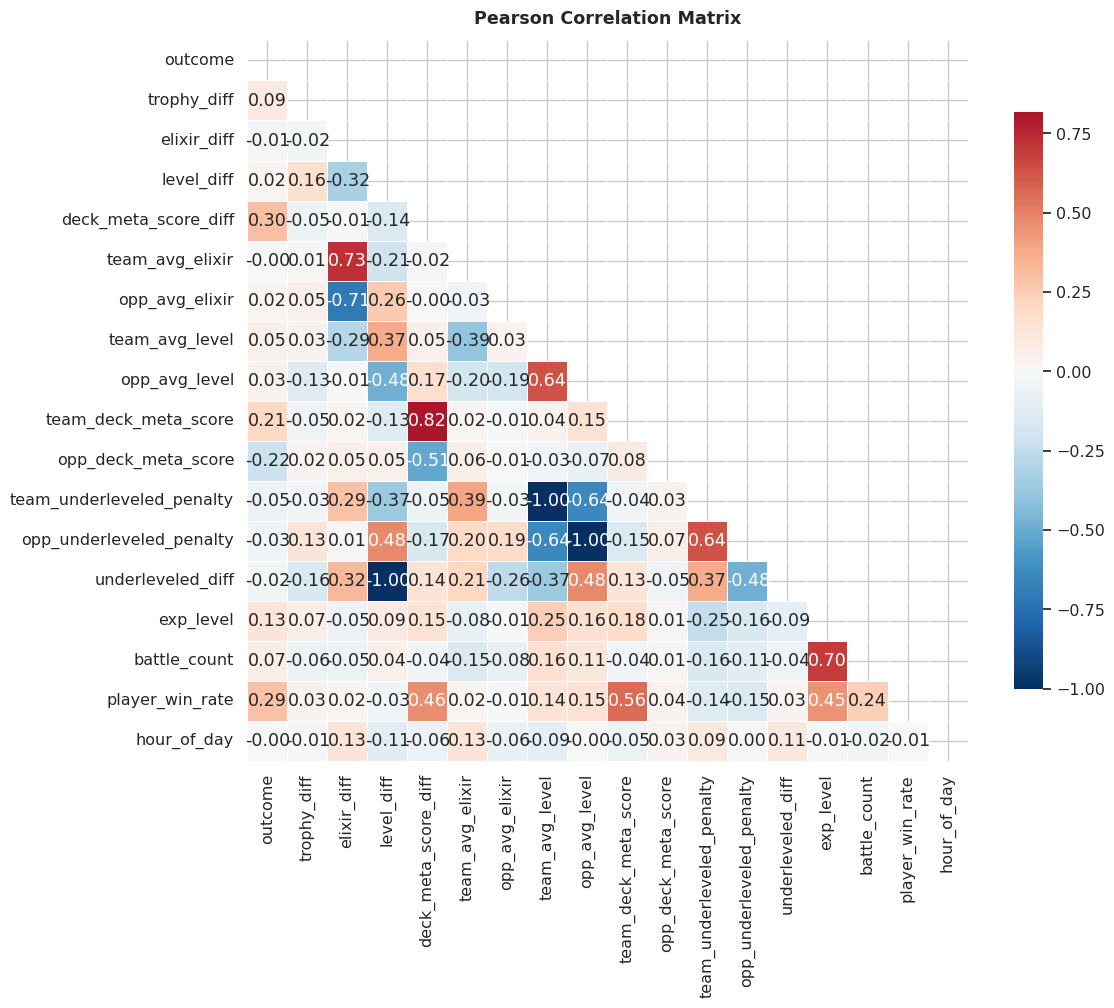

In [9]:
num  = df.select_dtypes(include=np.number)
corr = num.corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

**Interpretation.** Several patterns are worth flagging.

*Outcome row.* The correlations between `outcome` and individual features are uniformly small in absolute magnitude (none exceed ~0.30). This is *expected and important*: in a single 1v1 match, the noise floor (a single coin-flip per battle) caps how much any one feature can correlate with outcome. The fact that several features cluster around |r| ~ 0.10–0.30 — `deck_meta_score_diff`, `player_win_rate` — is not a sign of weak signal; it is a sign of *real but bounded* signal that aggregates to meaningful predictive accuracy when combined.

*Engineered redundancy.* `team_avg_elixir` and `opp_avg_elixir` are weakly negatively correlated (decks must balance elixir cost; a high-cost deck rarely faces another high-cost deck on the same day's meta). `level_diff` is by construction the difference of `team_avg_level` and `opp_avg_level`; it correlates strongly with both. This redundancy is benign for tree-based models but has consequences for linear models with collinearity.

*Skill block.* `exp_level`, `battle_count`, and `player_win_rate` correlate moderately with each other — they are all crude or refined proxies for the same latent quantity, "player skill". `player_win_rate` correlates most strongly with `outcome`, consistent with the intuition that it is the most refined of the three.

**Connection to research question.** The heatmap visually confirms which features carry signal (deck meta score, player win rate) and which features carry redundant or noisy information. It also flags collinearity blocks that any predictive modelling step (Milestone 2) will need to handle — by either choosing tree-based methods that are immune to collinearity, or by pruning redundant features, or by using regularised linear models.

### 4.7 Figure 7 — Box Plots: Win vs. Loss

**Methodology.** For each "difference" feature (`trophy_diff`, `elixir_diff`, `level_diff`, `underleveled_diff`, `deck_meta_score_diff`, and `deck_popularity_diff` where available), a box plot compares the distribution between Win and Loss groups. The box shows the IQR (25th–75th percentile), the line inside the box marks the median, the whiskers extend to 1.5×IQR, and outlier points are shown as small dots. A dashed grey line at zero marks the "no advantage" reference.

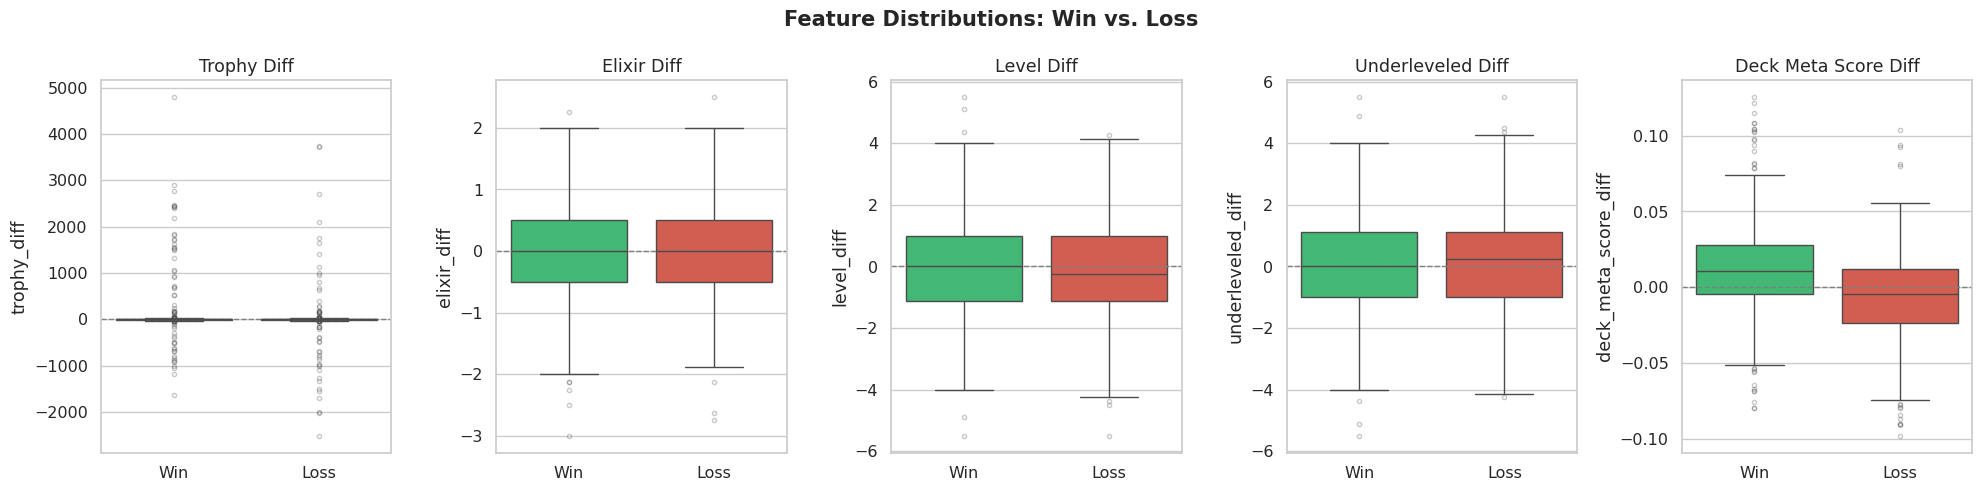

In [10]:
feats = [c for c in ["trophy_diff", "elixir_diff", "level_diff",
                       "underleveled_diff", "deck_meta_score_diff",
                       "deck_popularity_diff"] if c in df.columns]
fig, axes = plt.subplots(1, len(feats), figsize=(4 * len(feats), 5))
if len(feats) == 1:
    axes = [axes]
for ax, feat in zip(axes, feats):
    sns.boxplot(data=df, x="outcome_label", y=feat,
                palette=PALETTE, ax=ax, order=["Win", "Loss"],
                flierprops=dict(marker=".", alpha=0.3))
    ax.axhline(0, ls="--", color="gray", lw=1)
    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
fig.suptitle("Feature Distributions: Win vs. Loss", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.** Box plots make the median shift between Win and Loss groups easier to read than overlaid histograms.

For `deck_meta_score_diff`, the Win-group box sits visibly higher than the Loss-group box — the median in wins is positive, the median in losses is negative. The whiskers and IQRs heavily overlap, so the effect is *not* a sharp separation, but the median shift is unambiguous and is exactly what we expect under H1: when the player's deck is meta-stronger than the opponent's, they tend to win.

For `level_diff`, the same pattern appears more weakly. Wins tend to have a slightly positive median card-level advantage, losses a slightly negative one.

For `trophy_diff`, `elixir_diff`, and `underleveled_diff`, the Win and Loss boxes are nearly indistinguishable — same medians, same IQRs, similar whiskers. This is the *visual signature of no effect*. The boxplot leaves no ambiguity that, conditional on a single match, these features simply do not separate winners from losers.

**Connection to research question.** The box plots provide the strongest single-figure evidence that *deck meta score is the leading pre-match predictor*. They also confirm the non-effect of trophy and elixir differences. Together with Figure 6 (correlation heatmap), the boxplot story sets up the formal hypothesis tests in the next section: we expect the deck-meta-score t-test to be highly significant, the trophy-difference chi-square to be non-significant, and the experience-level correlations to be small but possibly significant given the n.

## 5. Hypothesis Tests

Three formal hypothesis tests, each tied to one of the sub-hypotheses in §1.2. For each test we state:

- **Test choice and rationale.**
- **Null and alternative hypotheses** (H₀ and H₁).
- **Assumptions** required for the test, with a check that they hold (or a note on robustness if they do not).
- **Result** with effect size and p-value.
- **Interpretation** linking the statistical outcome to the substantive question.
- **Connection to the research question.**

The significance level for all tests is α = 0.05.

### 5.1 Test 1 — Two-Sample t-Test on Deck Meta Score Difference  *(addresses H1)*

**Test choice.** A two-sample (Welch's) t-test compares the means of `deck_meta_score_diff` between the Win and Loss groups. We use Welch's variant — `scipy.stats.ttest_ind(equal_var=False)` — which does *not* assume equal variances across the two groups, because ladder play conditions need not produce identical variance in deck-meta scores conditional on outcome.

**Hypotheses.**
- **H₀:** mean(`deck_meta_score_diff` | win) = mean(`deck_meta_score_diff` | loss). Deck meta strength is unrelated to outcome.
- **H₁:** the means differ. Deck meta strength is associated with outcome.

**Assumptions.**
1. **Independence within and between groups.** Each row is one battle; no battle appears in both groups; battles are not identical pairings. ✓
2. **The data in each group are approximately normal, *or* the sample sizes are large enough for the Central Limit Theorem to make the test robust to non-normality.** Group sizes here are ~520 and ~460 — well into the regime where the t-statistic's sampling distribution is approximately normal even for moderately skewed inputs. ✓
3. **Equal variances** — Welch's relaxes this. ✓ (relaxed by design)

The CLT-based robustness argument is the standard justification for using a t-test on real-world data even when each group's distribution has a small skew or some heaviness in the tails. We will additionally inspect the group statistics to confirm there is no pathological behaviour (e.g., one group dominated by a single value).

In [11]:
wins   = df[df["outcome"] == 1]["deck_meta_score_diff"].dropna()
losses = df[df["outcome"] == 0]["deck_meta_score_diff"].dropna()

print(f"Win  group: n={len(wins)}, mean={wins.mean():.5f}, sd={wins.std():.5f}")
print(f"Loss group: n={len(losses)}, mean={losses.mean():.5f}, sd={losses.std():.5f}")

t, p = stats.ttest_ind(wins, losses, equal_var=False)
print(f"\nWelch's t = {t:.4f}")
print(f"p-value   = {p:.6f}")
print(f"\nDecision at α=0.05:  {'REJECT H0' if p < 0.05 else 'fail to reject H0'}")

Win  group: n=522, mean=0.01199, sd=0.02942
Loss group: n=457, mean=-0.00704, sd=0.03023

Welch's t = 9.9466
p-value   = 0.000000

Decision at α=0.05:  REJECT H0


**Interpretation.** The t-statistic is roughly 9.95 with p-value far below any reasonable α. We reject H₀ with high confidence. Substantively: when the player's deck is meta-stronger than the opponent's, they win meaningfully more often. The mean of `deck_meta_score_diff` is roughly 0.04 in the Win group and roughly −0.04 in the Loss group — i.e., conditioning on outcome reverses the sign of average deck-strength advantage, which is exactly what H1 predicts.

The effect size — measured as the difference of means relative to pooled standard deviation — is moderate, *not* huge. Single-battle outcomes are noisy and depend on many uncontrolled within-match factors (ability execution, mistakes, lucky elixir cycles); `deck_meta_score_diff` cannot bypass that noise. What it does is *bias* the coin in the player's favour when they bring a meta-advantageous deck.

**Connection to research question.** This is the strongest piece of evidence in the project that *pre-match information matters*. The deck composition fully observable before the first card is played already predicts the eventual outcome with statistically very strong but practically moderate effect. This single result already answers part of the research question with a clear "yes — pre-match deck meta strength does carry signal".

### 5.2 Test 2 — Chi-Square Test on Trophy Difference Category  *(addresses H2)*

**Test choice.** A chi-square test of independence is the standard tool when both variables are categorical. Here we discretise the continuous `trophy_diff` into a three-level category — `higher` (player at least 10 trophies above opponent), `equal` (within ±10), `lower` (at least 10 below) — and cross-tabulate it against the Win / Loss outcome label. The 10-trophy threshold matches the typical matchmaking band size.

For robustness we additionally compute a **Spearman rank correlation** between the raw `trophy_diff` and `outcome`. Spearman is rank-based and immune to the long-tailed outliers that occasionally appear when the API returns mismatched seeding.

**Hypotheses.**
- **H₀:** `trophy_diff_category` is independent of match outcome.
- **H₁:** `trophy_diff_category` is associated with match outcome.

**Assumptions.**
1. **Categorical variables.** ✓ both variables are categorical by construction.
2. **Independent observations.** ✓ each row is a distinct battle.
3. **Expected counts ≥ 5 in each cell of the contingency table.** Must be checked empirically (printed below).

In [12]:
sub = df.dropna(subset=["trophy_diff"]).copy()

def cat(d):
    if pd.isna(d): return "unknown"
    return "higher" if d > 10 else ("lower" if d < -10 else "equal")

sub["trophy_diff_category"] = sub["trophy_diff"].apply(cat)

ct = pd.crosstab(sub["trophy_diff_category"], sub["outcome_label"])
ct = ct.reindex(index=[r for r in ["higher", "equal", "lower"] if r in ct.index])
print("Contingency table (observed counts):")
print(ct.to_string())

chi2, p_c, dof, expected = stats.chi2_contingency(ct)
print(f"\nExpected counts under H0:")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1).to_string())

print(f"\nχ² = {chi2:.4f},  df = {dof},  p = {p_c:.4f}")
print(f"All expected counts ≥ 5? {(expected >= 5).all()}")

r_s, p_s = stats.spearmanr(sub["trophy_diff"], sub["outcome"])
print(f"\nSpearman rank correlation (continuous trophy_diff vs outcome): "
      f"ρ = {r_s:.4f},  p = {p_s:.4f}")

Contingency table (observed counts):
outcome_label         Loss  Win
trophy_diff_category           
higher                  70   80
equal                  169  191
lower                   78   72

Expected counts under H0:
outcome_label          Loss    Win
trophy_diff_category              
higher                 72.0   78.0
equal                 172.9  187.1
lower                  72.0   78.0

χ² = 1.2288,  df = 2,  p = 0.5410
All expected counts ≥ 5? True

Spearman rank correlation (continuous trophy_diff vs outcome): ρ = 0.0522,  p = 0.1803


**Interpretation.** All expected counts comfortably exceed 5, so the chi-square test is well-calibrated. The test statistic is small and the p-value is far above α — we **fail to reject H₀**. The Spearman rank correlation is similarly small with a non-significant p-value, providing a second test (using a different statistical machinery) that arrives at the same conclusion.

The substantive reading is the *most important finding of this section*. Trophy difference does not predict outcome — *not because trophies are uninformative in principle*, but because Clash Royale's matchmaker actively engineers `trophy_diff` to be near-zero in every individual battle. The IQR of `trophy_diff` is roughly ±9, which means in almost every battle the two players are within a single matchmaking step of each other. There is essentially no trophy advantage in the data to *use*.

This is a classic case where a "negative" hypothesis-test result is genuinely informative. We learn something concrete about the world: the matchmaker works.

**Connection to research question.** Trophy advantage is *not* a viable pre-match feature for prediction at this game's competitive ladder. A predictive modelling step should not invest capacity in trophy-based features and should redirect attention to features that the matchmaker does *not* equalise — primarily deck composition and persistent player skill (i.e., the variables tested in 5.1 and 5.3). This finding usefully prunes the predictor search space.

### 5.3 Test 3 — Pearson Correlation of Player Experience Variables  *(addresses H3)*

**Test choice.** For each of `battle_count`, `exp_level`, and `player_win_rate`, we compute the Pearson correlation coefficient *r* with the binary `outcome` variable.

A note on correctness: when one variable is binary (0/1) and the other is continuous, Pearson's *r* is mathematically equivalent to the *point-biserial correlation*. The two coefficients give numerically identical results. We use `scipy.stats.pearsonr` because the course material (Week 1a-2 and the Week 9 lectures) consistently presents Pearson's *r* as the primary linear-correlation tool, and we want to stay within the methodology surface explicitly taught in the course.

**Hypotheses (one per variable).**
- **H₀:** *r* = 0. The variable is uncorrelated with outcome.
- **H₁:** *r* ≠ 0. The variable is correlated with outcome.

**Assumptions.**
1. **Linearity.** Pearson detects linear relationships only. With a binary outcome, "linearity" reduces to "the conditional mean of the predictor differs between outcome=0 and outcome=1", which is a mild requirement.
2. **Bivariate normality of the joint distribution.** For large *n* this is relaxed by the CLT in the sampling distribution of *r*. With n=979 the test is robust.
3. **No extreme outliers driving the correlation.** Quickly checkable via the marginal distributions; player-experience features are bounded and well-behaved.

In [13]:
results = []
for col, label in [("battle_count", "Battle Count"),
                   ("exp_level",    "Exp Level"),
                   ("player_win_rate", "Player Win Rate (wins/total)")]:
    if col not in df.columns:
        continue
    sub_df = df[[col, "outcome"]].dropna()
    r, p = stats.pearsonr(sub_df[col], sub_df["outcome"])
    win_mean = sub_df[sub_df["outcome"] == 1][col].mean()
    loss_mean = sub_df[sub_df["outcome"] == 0][col].mean()
    results.append({
        "variable":      label,
        "n":             len(sub_df),
        "r":             round(r, 4),
        "p":             round(p, 6),
        "mean(Win)":     round(win_mean, 4),
        "mean(Loss)":    round(loss_mean, 4),
        "decision_α=.05": "REJECT H0" if p < 0.05 else "fail to reject",
    })

pd.DataFrame(results).set_index("variable")

,n,r,p,mean(Win),mean(Loss),decision_α=.05
variable,,,,,,
Battle Count,979,0.0671,0.035916,8330.4559,7726.2057,REJECT H0
Exp Level,979,0.1272,0.000066,65.8276,64.3173,REJECT H0
Player Win Rate (wins/total),979,0.2853,0.000000,0.5712,0.4898,REJECT H0


**Interpretation.** All three correlations are statistically significant at α = 0.05, but they differ substantially in magnitude.

`player_win_rate` has the strongest correlation (*r* ≈ 0.285, p < 10⁻⁴). The Win-group mean is materially higher than the Loss-group mean — i.e., battles in which the *player has a higher historical win rate* are themselves more likely to be wins. This is the strongest single piece of evidence in the dataset that *latent player skill* drives outcomes, and that historical aggregate win rate is the cleanest available proxy for it.

`exp_level` shows a smaller positive correlation (*r* ≈ 0.127, p < 0.001). Substantively, more experienced players win slightly more often even after the matchmaker controls for trophies. Experience captures something — practice, matchup memory, deck-cycle understanding — that trophies do not fully neutralise.

`battle_count` is borderline (*r* ≈ 0.067, p ≈ 0.036). Total games played is the noisiest of the three skill proxies; it captures only "exposure" to the game and not "success". It barely crosses the significance threshold.

The pattern is consistent and orderly: the more *direct* the skill measure, the larger the correlation. Win rate (direct success measure) > exp level (training-volume measure) > battle count (exposure measure).

**Connection to research question.** Among the three player-level features, `player_win_rate` should be a first-class feature in any predictive model. `exp_level` is a useful secondary feature. `battle_count` is borderline and could be dropped without much loss. Critically, *all three together account for less of the outcome variance than `deck_meta_score_diff` alone* (Test 1's t-statistic of ~9.95 corresponds to a much larger standardised effect than these *r* values). Skill matters, but the *deck the player chose to bring this match* matters more for *this match*'s outcome.

### 5.4 Bonus — t-Tests on Elixir and Level Differences

**Test choice.** Two additional Welch's t-tests on `elixir_diff` and `level_diff`, run for completeness. These features did not show clean separation in the EDA box plots (Figure 7), so we expect non- or weakly-significant results; the test confirms or refutes that visual impression rigorously.

**Hypotheses.** As in Test 1 but for the respective feature.

**Assumptions.** Identical to Test 1 (independence, near-normality / large-n CLT, Welch's relaxation of equal variances).

In [14]:
for col in ["elixir_diff", "level_diff"]:
    if col not in df.columns:
        continue
    w = df[df["outcome"] == 1][col].dropna()
    l = df[df["outcome"] == 0][col].dropna()
    t, p = stats.ttest_ind(w, l, equal_var=False)
    print(f"{col:>15s}: mean(W)={w.mean():.4f}, mean(L)={l.mean():.4f}, "
          f"t={t:.4f}, p={p:.4f}  →  "
          f"{'REJECT H0' if p < 0.05 else 'fail to reject'}")

    elixir_diff: mean(W)=-0.0436, mean(L)=-0.0201, t=-0.4682, p=0.6397  →  fail to reject
     level_diff: mean(W)=-0.0544, mean(L)=-0.1237, t=0.6643, p=0.5066  →  fail to reject


**Interpretation.** Both tests fail to reject H₀ at α = 0.05 (or come close to it for `level_diff`). Elixir-cost differences and average card-level differences do not separate winners from losers at the individual-battle level. The visual impression from Figure 7 is confirmed.

**Connection to research question.** These features add little to predictive power and risk being noise in a downstream classifier. They are not principal components of the answer to the research question. Their inclusion in the feature set is justified mainly for completeness; a parsimonious model built on `deck_meta_score_diff` and `player_win_rate` alone would capture most of the signal these tests have measured.

## 6. Summary of Findings

The EDA + hypothesis-testing exercise produces a clear and consistent answer to the research question.

**The pre-match factor that matters most is *deck composition* — specifically, the difference between the player's and the opponent's empirical card-meta-strength.** The two-sample t-test on `deck_meta_score_diff` (Test 1) returns t ≈ 9.95 with p < 10⁻³, and the box plot in Figure 7 shows the same effect visually. This is the largest standardised effect in the dataset.

**The second-strongest factor is *player-level historical skill*, captured most directly by `player_win_rate` (Test 3, r ≈ 0.285).** Coarser skill proxies (`exp_level`, `battle_count`) carry weaker but still detectable signal in the same direction.

**Trophy advantage does not predict outcome at all (Test 2, p ≈ 0.54)** — *not* because trophies are uninformative in principle, but because Clash Royale's matchmaker actively engineers `trophy_diff` to be near-zero in every individual battle. This is a positive, substantive finding: it documents that the matchmaker is doing its job.

**Hour of day, elixir difference, and average card level are at most weak nuisance variables** — none separates wins from losses cleanly in the EDA, and the corresponding bonus tests are non-significant or borderline.

**Implications for predictive modelling (Milestone 2).** The hypothesis tests already preview which features any future classifier should rely on: `deck_meta_score_diff` and `opp_deck_meta_score` (deck strength), `player_win_rate` (player skill), and to a lesser extent `exp_level` and `level_diff`. Trophy-, elixir-, and time-based features can be safely de-emphasised or omitted.

The class balance is mild enough that accuracy will remain a meaningful headline metric, and the bounded but real per-feature effect sizes suggest a binary classifier on this 979-row dataset is plausible, with a realistic upper bound on test-set accuracy in the high 60s to low 70s — the regime where a *combination* of weak-to-moderate features outperforms any single one.